### Desarrollo Proyecto Web Scrapping

Decidí tomar la Opción B: Propuesta sugerida – Scrapthissite.com

In [6]:
import pandas as pd
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import io


In [7]:
url = "https://www.scrapethissite.com/pages/forms/"
response = requests.get(url)

In [9]:
if response.status_code == 200:
    tablas = pd.read_html(io.StringIO(response.text))
    df = tablas[0]
    print(df.head())
else:
    print('Error al descargar la pagina', response.status_code)

            Team Name  Year  Wins  Losses  OT Losses  Win %  Goals For (GF)  \
0       Boston Bruins  1990    44      24        NaN  0.550             299   
1      Buffalo Sabres  1990    31      30        NaN  0.388             292   
2      Calgary Flames  1990    46      26        NaN  0.575             344   
3  Chicago Blackhawks  1990    49      23        NaN  0.613             284   
4   Detroit Red Wings  1990    34      38        NaN  0.425             273   

   Goals Against (GA)  + / -  
0                 264     35  
1                 278     14  
2                 263     81  
3                 211     73  
4                 298    -25  


### Procesamiento del DataFrame

In [ ]:
df = df.dropna(how='all')  #El how=all, elimina toda la fila si todas las columnas tienen NaN 
df = df.reset_index(drop=True)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Team Name           25 non-null     str    
 1   Year                25 non-null     int64  
 2   Wins                25 non-null     int64  
 3   Losses              25 non-null     int64  
 4   OT Losses           0 non-null      float64
 5   Win %               25 non-null     float64
 6   Goals For (GF)      25 non-null     int64  
 7   Goals Against (GA)  25 non-null     int64  
 8   + / -               25 non-null     int64  
dtypes: float64(2), int64(6), str(1)
memory usage: 1.9 KB
None


### Almacenamiento de los datos sqlite 

In [11]:
conn = sqlite3.connect('hockey.db')
df.to_sql('equipos', conn, if_exists='replace', index = False)
conn.commit()
conn.close()

### Visualización de Datos

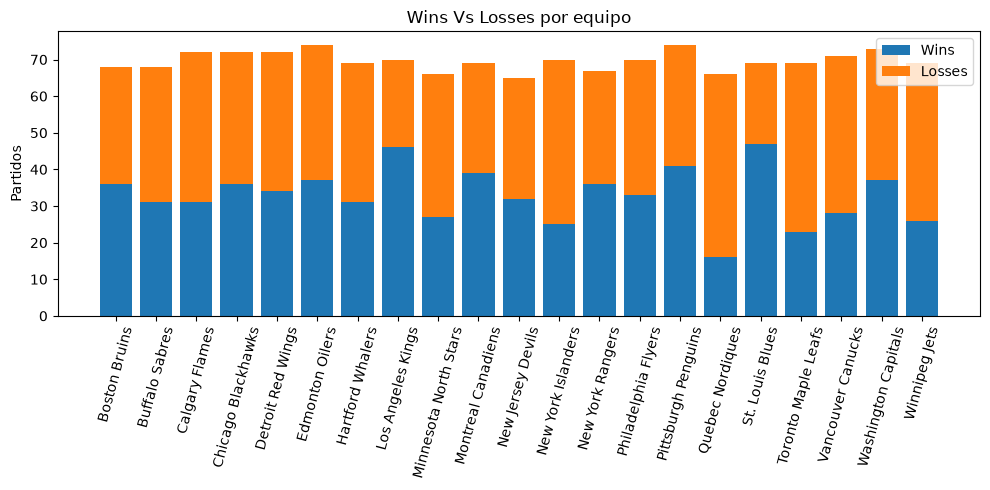

In [12]:
#1. Grafica de barras: Wins Vs Losses por equipo

plt.figure(figsize=(10,5))
plt.bar(df['Team Name'], df['Wins'], label='Wins')
plt.bar(df['Team Name'], df['Losses'], bottom=df['Wins'], label='Losses')
plt.xticks(rotation=75)
plt.ylabel('Partidos')
plt.title('Wins Vs Losses por equipo')
plt.legend()
plt.tight_layout()
plt.show()

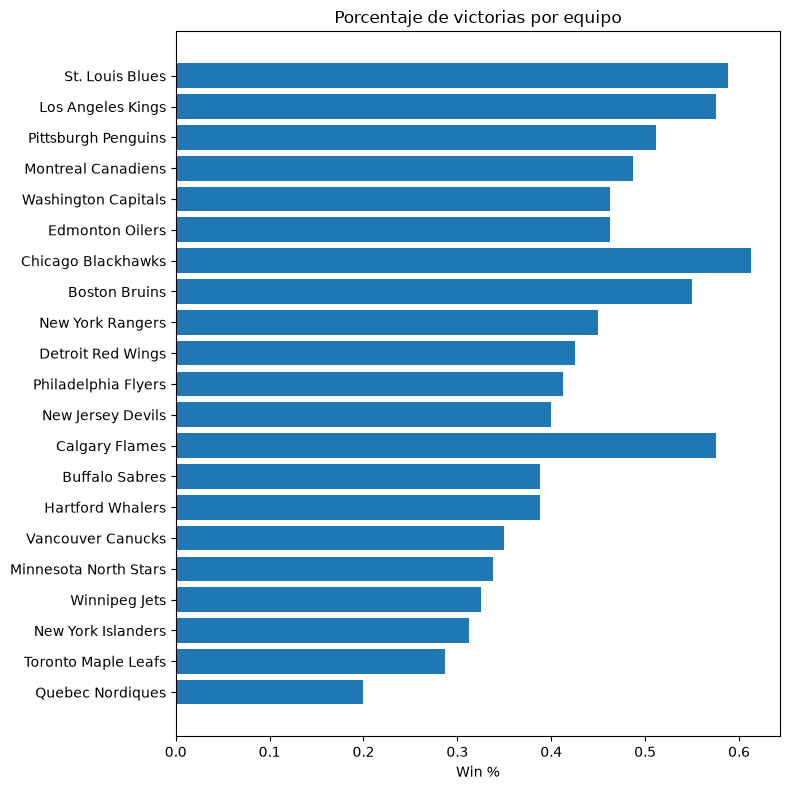

In [13]:
#2. Diagrama de barras: Win % ordenado de mayor a menor

df_sorted = df.sort_values('Win %', ascending=True)
plt.figure(figsize=(8, 8))
plt.barh(df_sorted['Team Name'], df_sorted['Win %'])
plt.xlabel('Win %')
plt.title('Porcentaje de victorias por equipo')
plt.tight_layout()
plt.show()

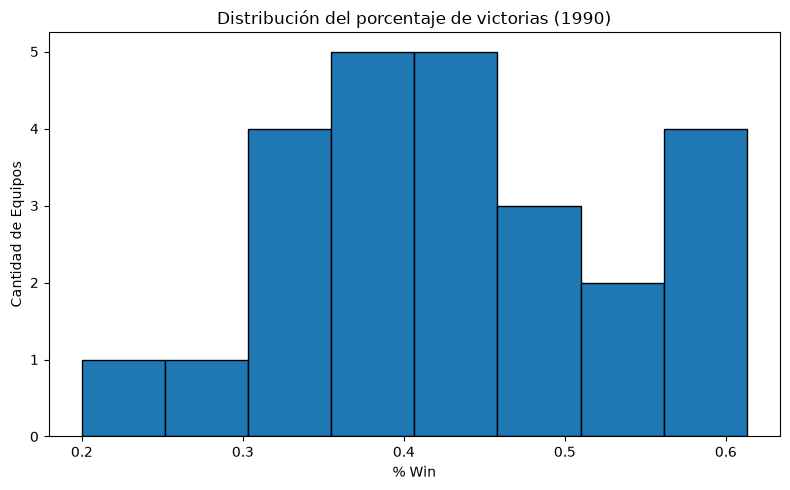

In [15]:
#3. Histograma del % Win

plt.figure(figsize=(8, 5))
plt.hist(df['Win %'], bins = 8, edgecolor='black')
plt.xlabel('% Win')
plt.ylabel('Cantidad de Equipos')
plt.title('Distribución del porcentaje de victorias (1990)')
plt.tight_layout()
plt.show()